In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Load dataset

df = pd.read_csv('/content/Housing.csv')

# Display first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
print(df.shape)


(545, 13)


In [ ]:
print(df.columns)


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
# Create label encoder
le = LabelEncoder()

# Convert categorical columns

categorical_columns = [
    'price',
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea',
    'furnishingstatus'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Display dataset
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,218,232,3,1,2,1,0,0,0,1,2,1,0
1,217,260,3,3,3,1,0,0,0,1,3,0,0
2,217,268,2,1,1,1,0,1,0,0,2,1,1
3,216,237,3,1,1,1,0,1,0,1,3,1,0
4,215,232,3,0,1,1,1,1,0,1,2,0,0


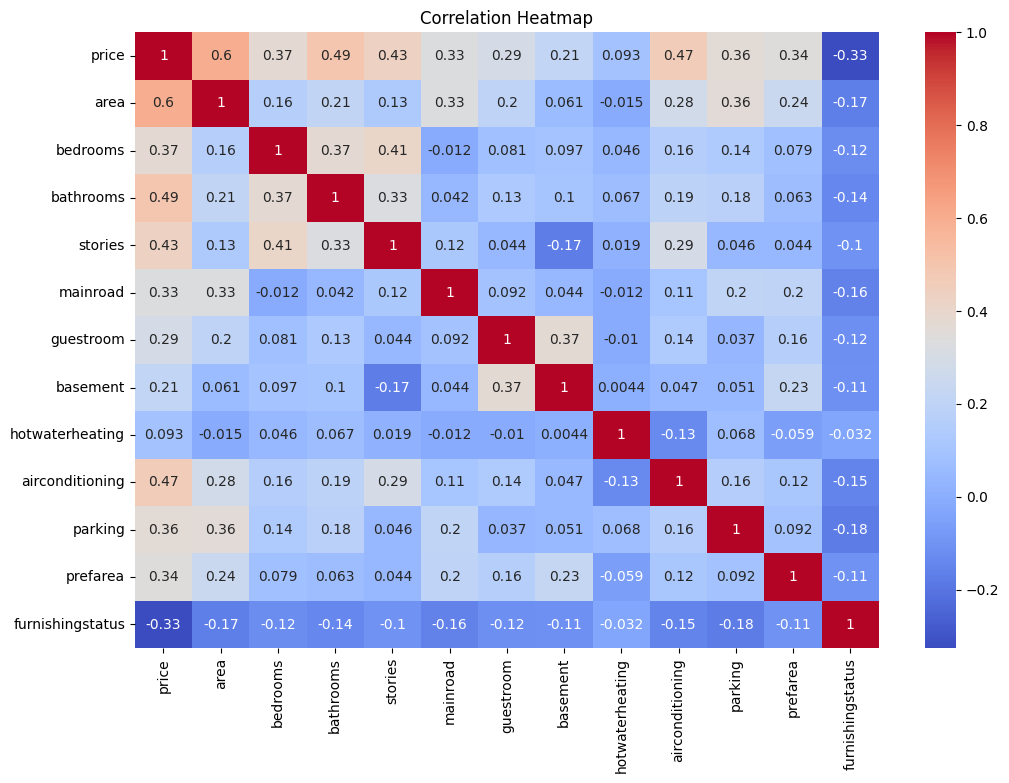

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

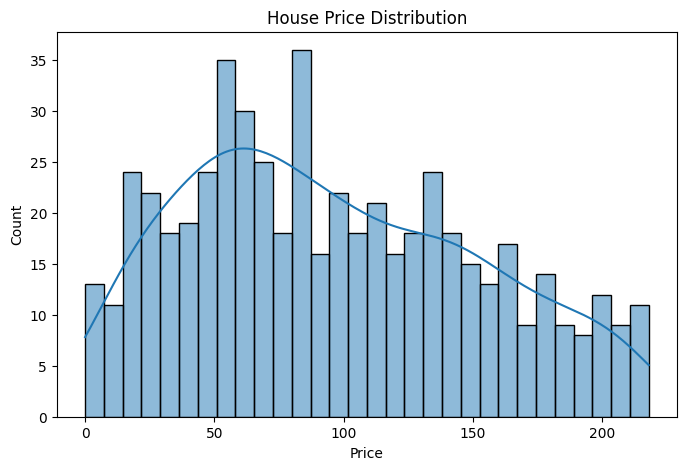

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

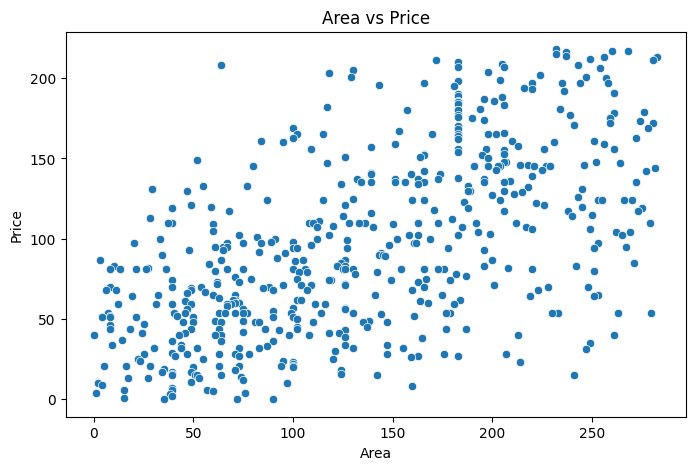

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['area'], y=df['price'])

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

In [ ]:
# Independent variables
X = df.drop('price', axis=1)

# Dependent variable
y = df['price']

print(X.head())
print(y.head())

   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0   232         3          1        2         1          0         0   
1   260         3          3        3         1          0         0   
2   268         2          1        1         1          0         1   
3   237         3          1        1         1          0         1   
4   232         3          0        1         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                0                1        2         1                 0  
1                0                1        3         0                 0  
2                0                0        2         1                 1  
3                0                1        3         1                 0  
4                0                1        2         0                 0  
0    218
1    217
2    217
3    216
4    215
Name: price, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 12)
(109, 12)


In [ ]:
# Create model

model = LinearRegression()

# Train model

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
# Predict values

y_pred = model.predict(X_test)

print(y_pred[:5])

[111.60538514 177.62965495  45.6232247   95.72424779  54.92190774]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 29.22827232945923
Mean Squared Error: 1304.4085254256677
Root Mean Squared Error: 36.11659626024672
R2 Score: 0.6792935435513783


In [ ]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
316,74,111.605385
77,165,177.629655
360,62,45.623225
90,159,95.724248
493,24,54.921908
209,110,68.427803
176,124,125.951487
249,96,154.157903
516,15,24.490965
426,47,25.076712


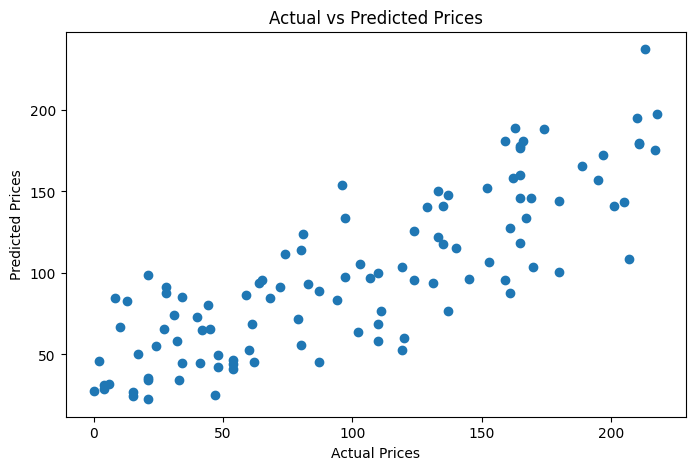